In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\1_comp
scenario=1comp  K_MODEL=5  K_TRUE=1
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth, Grids (Full + Chebyshev) & Trimmed Mass ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's pooled-marginal mean +/- 5*std (exact moments via
#                 the law of total variance), so >= 96% of each model's marginal
#                 mass is guaranteed inside for any distribution.
# Trimmed-mass tables report the realised trim EXACTLY (mixture CDF, no grid
# error) - equal to the renormalisation each density receives in Cell 5. The
# window is symmetric in x, not in mass: the left/right split shows the skew.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

for label, grids in GRIDS.items():
    trimmed = {m["name"]: (1.0 - mc.retained_mass(m, grids)) * 100.0
               for m in models + [true_model]}
    print(f"\nMass trimmed by the [{label}] window, in % of each marginal:")
    display(pd.DataFrame(trimmed, index=param_names).T.round(4))

cheb = GRIDS["Chebyshev (k=5, >=96%)"]
split = {}
for m in models + [true_model]:
    l, r = mc.trimmed_tails(m, cheb)
    split[m["name"]] = np.r_[l, r] * 100.0
cols = pd.MultiIndex.from_product([["left tail", "right tail"], param_names])
print("\nChebyshev trim by side, in % of each marginal:")
display(pd.DataFrame(split, index=cols).T.round(4))

Grid extents [Full]:
  Alt1       [-2116.00, +2253.07]
  Alt2       [-1431.95, +1491.98]
  Alt3       [-1103.55, +1171.63]
  Price      [-489.80, +318.29]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-12.60, +15.26]
  Alt2       [-8.64, +16.45]
  Alt3       [-6.25, +12.26]
  Price      [-10.57, +5.36]

Mass trimmed by the [Full] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0,0.0,0.0,0.0
HMC,0.0,0.0,0.0,0.0
NUTS,0.0,0.0,0.0,0.0
replication,0.0,0.0,0.0,0.0
True DGP,0.0,0.0,0.0,0.0



Mass trimmed by the [Chebyshev (k=5, >=96%)] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0497,0.0785,0.1793,0.3276
HMC,0.2481,0.2478,0.3922,0.6057
NUTS,0.2242,0.2155,0.2631,0.3268
replication,0.0545,0.0822,0.2340,0.3913
True DGP,0.0000,0.0000,0.0000,0.0000



Chebyshev trim by side, in % of each marginal:


left tail                         right tail                  \
                 Alt1    Alt2    Alt3   Price       Alt1    Alt2    Alt3   
bayesm         0.0333  0.0626  0.1312  0.1954     0.0164  0.0158  0.0481   
HMC            0.1367  0.1389  0.2391  0.4499     0.1114  0.1089  0.1531   
NUTS           0.1270  0.1343  0.1728  0.1730     0.0972  0.0812  0.0903   
replication    0.0386  0.0598  0.1738  0.2675     0.0159  0.0224  0.0601   
True DGP       0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   

                     
              Price  
bayesm       0.1321  
HMC          0.1558  
NUTS         0.1537  
replication  0.1238  
True DGP     0.0000

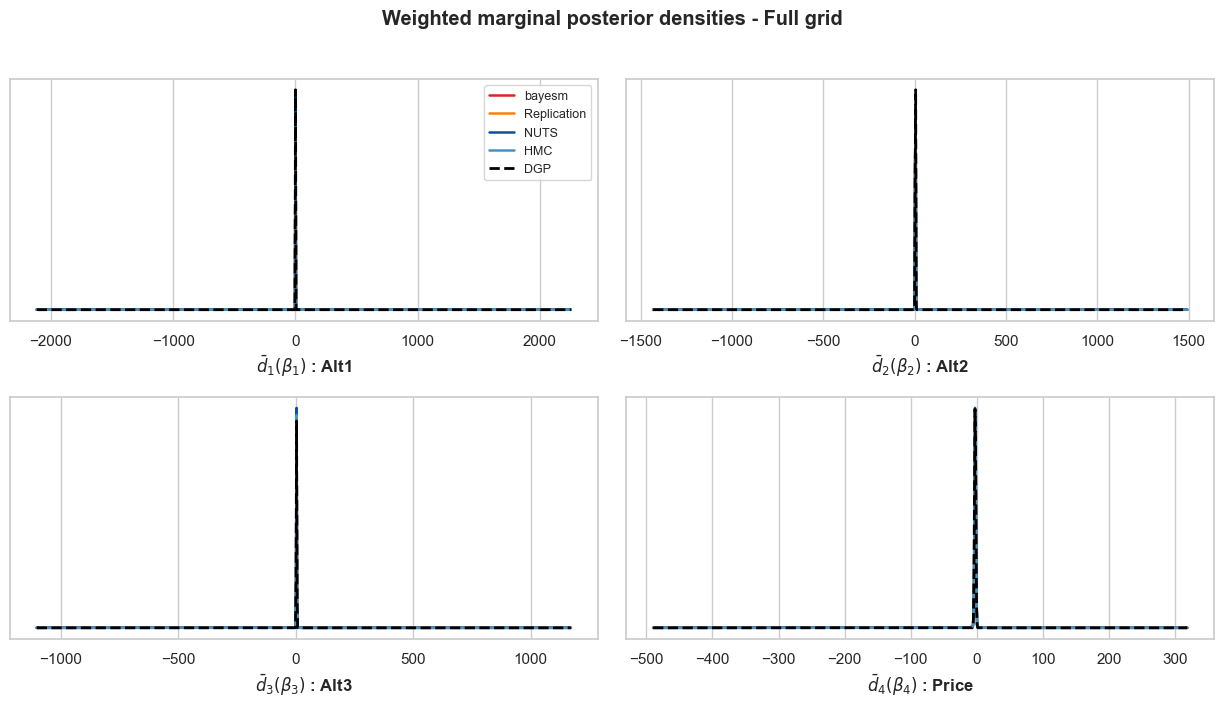

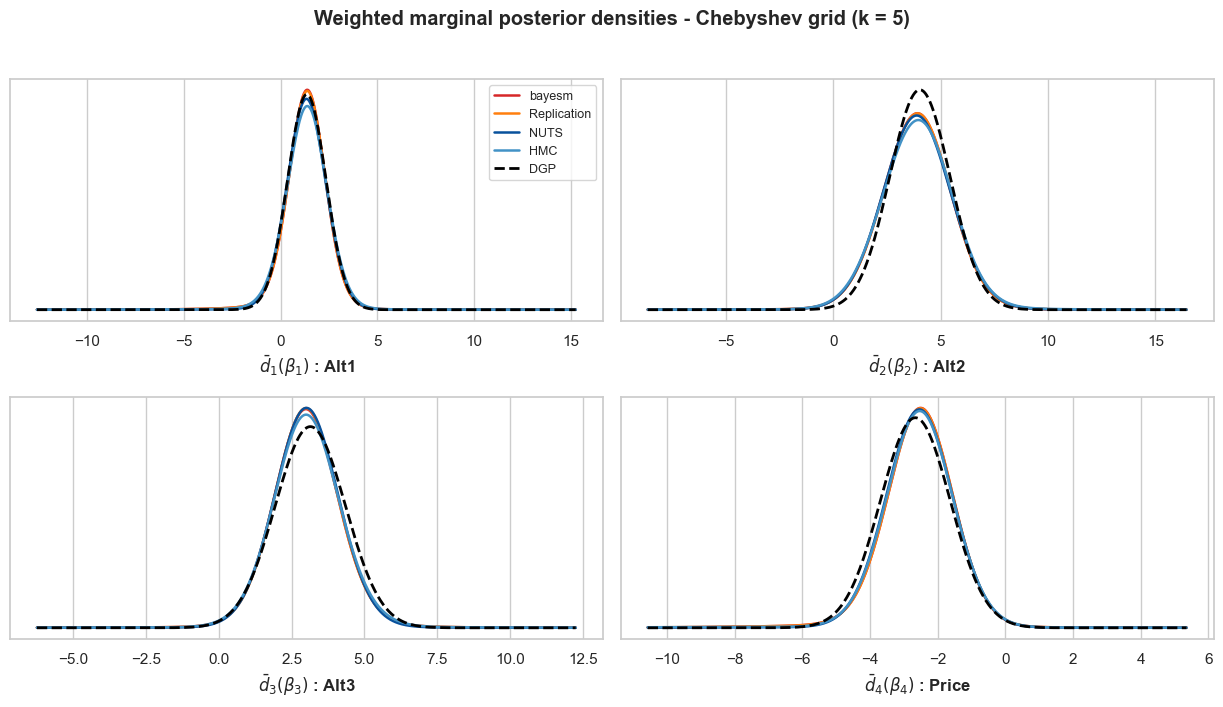

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass. Legend order: bayesm, Replication, NUTS, HMC, DGP.
# DGP dashed black, bayesm red, Replication orange, NUTS/HMC in blues.
# Densities are cached in DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728", "replication": "#ff7f0e"}
TRUE_COLOR = "#000000"
LEGEND_ORDER = ["bayesm", "replication", "NUTS", "HMC"]
DISPLAY_NAME = {"NUTS": "NUTS", "HMC": "HMC", "bayesm": "bayesm", "replication": "Replication"}
TITLE_SUFFIX = {"Full": "Full grid", "Chebyshev (k=5, >=96%)": "Chebyshev grid (k = 5)"}
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.6), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name in LEGEND_ORDER:
            if name not in dens:
                continue
            ax[j].plot(grids[j], dens[name][j], lw=1.8, label=DISPLAY_NAME[name],
                       color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="DGP")
        ax[j].set_xlabel(rf"$\bar{{d}}_{{{j+1}}}(\beta_{{{j+1}}})$ : {pj}", fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Weighted marginal posterior densities - {TITLE_SUFFIX.get(label, label)}",
                 fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): KL(model||true)
# and TVD. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:258: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


KL      TVD
sampler     param                  
bayesm      Alt1   0.16895  0.01172
            Alt2       inf  0.07492
            Alt3   0.15636  0.03995
            Price      inf  0.06056
HMC         Alt1   0.45606  0.01260
            Alt2       inf  0.07535
            Alt3   0.40651  0.02956
            Price      inf  0.05341
NUTS        Alt1   0.38165  0.00753
            Alt2       inf  0.08113
            Alt3   0.28441  0.04503
            Price      inf  0.04939
replication Alt1   0.17510  0.01149
            Alt2       inf  0.07274
            Alt3   0.19285  0.04418
            Price      inf  0.06113

--- Chebyshev (k=5, >=96%) ---


KL      TVD
sampler     param                  
bayesm      Alt1   0.14984  0.02527
            Alt2   0.05666  0.06577
            Alt3   0.04886  0.06089
            Price  0.08508  0.06353
HMC         Alt1   0.18382  0.03451
            Alt2   0.07823  0.07558
            Alt3   0.04827  0.05168
            Price  0.07399  0.05378
NUTS        Alt1   0.13084  0.01681
            Alt2   0.05837  0.07050
            Alt3   0.03531  0.05947
            Price  0.04375  0.05052
replication Alt1   0.15482  0.02374
            Alt2   0.06033  0.06504
            Alt3   0.05391  0.06141
            Price  0.09079  0.06362

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.298,1.326,1.312,1.297,1.349
Alt2,3.870,3.906,3.881,3.883,4.032
Alt3,2.994,3.004,2.996,2.994,3.141
Price,-2.576,-2.606,-2.559,-2.585,-2.659


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.660,7.721,4.868,1.665,0.980
Alt2,3.021,6.258,5.013,3.040,1.974
Alt3,1.911,3.403,2.634,2.023,1.454
Price,1.852,2.518,2.162,1.957,1.063


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

--- bayesm  (fit wall-clock: 427s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.001  1255.549  3254.336       2.940       7.621
      sd          1.001  1269.126  3379.682       2.972       7.915
      q05         1.006   655.460   854.380       1.535       2.001
      q50         1.001   795.103  1156.082       1.862       2.707
      q95         1.001   583.340  1379.140       1.366       3.230
Alt2  mean        1.002  1265.778  3955.504       2.964       9.263
      sd          1.001  1908.726  3601.102       4.470       8.433
      q05         1.001  2500.658  5879.650       5.856      13.770
      q50         1.001   875.584  1199.547       2.051       2.809
      q95         1.005   644.401  1149.708       1.509       2.693
Alt3  mean        1.002  1047.532  3262.878       2.453       7.641
      sd          1.002   761.469  2658.939       1.783       6.227
      q05         1.003  1046.512  3379.900       2.451       7.915
      q50         1.001  1115.617  2821.355       2.613       6.607
      q95         1.002   327.563   793.490       0.767       1.858
Price mean        1.009   416.484  1849.566       0.975       4.332
      sd          1.010   329.932  2072.420       0.773       4.853
      q05         1.006   343.826   730.047       0.805       1.710
      q50         1.002  1626.268  4910.065       3.809      11.499
      q95         1.002  2564.781  9553.515       6.007      22.374

--- HMC  (fit wall-clock: 447s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.006    96.092    74.068       0.215       0.166
      sd          1.018   109.293    59.780       0.245       0.134
      q05         1.108    15.134   250.694       0.034       0.561
      q50         1.038    66.000   144.591       0.148       0.323
      q95         1.089    21.547   370.612       0.048       0.829
Alt2  mean        1.026   105.508   322.621       0.236       0.722
      sd          1.015   118.320    89.505       0.265       0.200
      q05         1.017   355.991  1278.191       0.796       2.859
      q50         1.074    23.956    89.827       0.054       0.201
      q95         1.045    61.685   360.671       0.138       0.807
Alt3  mean        1.056    37.523   169.566       0.084       0.379
      sd          1.009    96.074   159.265       0.215       0.356
      q05         1.006   233.868   762.914       0.523       1.707
      q50         1.023   141.079   860.274       0.316       1.925
      q95         1.153    10.131    81.350       0.023       0.182
Price mean        1.184     7.700    61.551       0.017       0.138
      sd          1.122    11.248    75.977       0.025       0.170
      q05         1.113    13.469   267.615       0.030       0.599
      q50         1.009   359.403   923.926       0.804       2.067
      q95         1.005   866.531  1568.296       1.939       3.508

--- NUTS  (fit wall-clock: 2,255s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.026  1637.093   108.964       0.726       0.048
      sd          1.115    11.803   123.289       0.005       0.055
      q05         1.041    40.461   139.997       0.018       0.062
      q50         1.000  2176.567  2991.282       0.965       1.327
      q95         1.010  1068.765  2879.328       0.474       1.277
Alt2  mean        1.012  1593.097  2777.287       0.707       1.232
      sd          1.092    14.480   318.031       0.006       0.141
      q05         1.016   393.989  4251.891       0.175       1.886
      q50         1.000  1752.357  2241.581       0.777       0.994
      q95         1.018   823.158  1289.356       0.365       0.572
Alt3  mean        1.011  1832.080  2164.411       0.813       0.960
      sd          1.140     9.845   182.328       0.004       0.081
      q05         1.016   872.914  3758.807       0.387       1.667
      q50         1.000  2200.297  4804.348       0.976       2.131
      q95         1.010   869.511  2013.980       0.386       0.893
Price mean        1.029  1155.871   147.104       0.513       0.065
      sd          1.241     6.111    80.396       0.003       0.036
      q05         1.041    42.767    87.888       0.019       0.039
      q50         1.004  3550.369  7553.954       1.575       3.350
      q95         1.011   537.480  2606.881       0.238       1.156

--- replication  (fit wall-clock: 318s) ---


Rhat  ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                    
Alt1  mean        1.003   823.874   1818.785       2.588       5.714
      sd          1.003   564.883   1268.146       1.775       3.984
      q05         1.003   440.660    916.224       1.384       2.878
      q50         1.001   634.253   2106.881       1.993       6.619
      q95         1.004   605.226   1715.309       1.901       5.389
Alt2  mean        1.002   650.305   2799.508       2.043       8.795
      sd          1.001  1127.306   2912.475       3.542       9.150
      q05         1.002  1839.099   4654.669       5.778      14.624
      q50         1.002   662.232   1387.809       2.081       4.360
      q95         1.002   434.359   1426.306       1.365       4.481
Alt3  mean        1.003   329.780   1754.899       1.036       5.513
      sd          1.002   451.349   1485.608       1.418       4.667
      q05         1.001  1260.183   2902.799       3.959       9.120
      q50         1.000  1049.344   3473.553       3.297      10.913
      q95         1.003   224.957    678.017       0.707       2.130
Price mean        1.006   207.165    709.418       0.651       2.229
      sd          1.014   129.862   1013.948       0.408       3.186
      q05         1.007   183.628    432.083       0.577       1.357
      q50         1.002  1991.085   5519.114       6.255      17.339
      q95         1.000  3498.455  10011.709      10.991      31.454

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
